In [16]:
import time
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import linear_model, tree
from sklearn.neural_network import MLPRegressor
import shap

# SHAP for Model Explainability

This notebook shows how to use [SHAP](https://shap.readthedocs.io/) (SHapley Additive exPlanations) to explain the predictions of regression models trained on the sklearn **diabetes** dataset.

Three model types are trained and explained:
1. **Linear Regression** — explained with `KernelExplainer` (model-agnostic).
2. **Decision Tree Regressor** — explained with `TreeExplainer` (fast, exact explainer for tree-based models).
3. **MLP Regressor** (neural network) — explained with `KernelExplainer` (model-agnostic).

For each model we look at:
- **Force plots**: how each feature pushes a single prediction (or the whole test set) away from the baseline/expected value.
- **Summary plots**: global feature importance and the direction of each feature's effect across all test samples.
- **Dependence plots**: how a single feature's value relates to its SHAP value, and whether it interacts with another feature.


## Data Setup

Load the diabetes dataset and split it into train/test sets. Since `KernelExplainer` estimates SHAP values by sampling from a background distribution, the full training set is summarized into 10 weighted k-means clusters (`X_train_summary`) to keep the computation tractable. A helper `print_accuracy` function reports the RMSE of each model on the test set.


In [17]:
X, y = shap.datasets.diabetes()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# rather than use the whole training set to estimate expected values, we summarize with
# a set of weighted kmeans, each weighted by the number of points they represent.
X_train_summary = shap.kmeans(X_train, 10)


def print_accuracy(f):
    print(f"Root mean squared test error = {np.sqrt(np.mean((f(X_test) - y_test) ** 2))}")
    time.sleep(0.5)  # to let the print get out before any progress bars


shap.initjs()

## 1. Linear Regression

Train a plain `LinearRegression` model as our first baseline, then explain it with `KernelExplainer`:
- **Single-instance force plot**: SHAP values for one test sample, showing which features push the prediction above/below the expected value.
- **Summary plot**: overall feature importance and effect direction across the whole test set.
- **Dependence plot**: relationship between the `bmi` feature's value and its SHAP value.
- **Full force plot**: force plots for every test sample stacked into one interactive view.


In [18]:
lin_regr = linear_model.LinearRegression()
lin_regr.fit(X_train, y_train)

print_accuracy(lin_regr.predict)

Root mean squared test error = 58.517171277315626


In [19]:
shap.initjs()
ex = shap.KernelExplainer(lin_regr.predict, X_train_summary)
shap_values = ex.shap_values(X_test.iloc[0, :])
shap.force_plot(ex.expected_value, shap_values, X_test.iloc[0, :])

  0%|          | 0/89 [00:00<?, ?it/s]

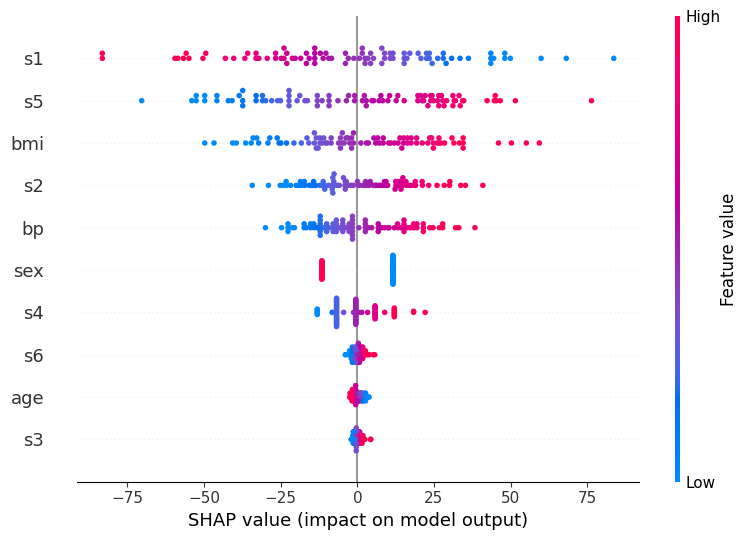

In [20]:
shap.initjs()
shap_values = ex.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

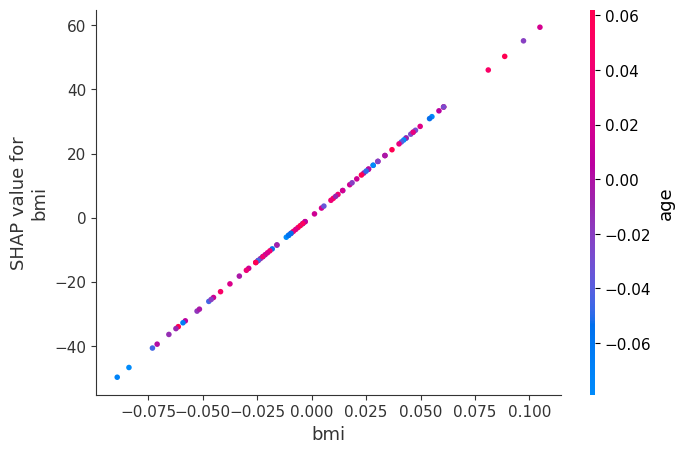

In [21]:
shap.initjs()
shap.dependence_plot("bmi", shap_values, X_test)

In [22]:
shap.initjs()
shap.force_plot(ex.expected_value, shap_values, X_test)

## 2. Decision Tree Regressor

Train a `DecisionTreeRegressor` (max depth 5) and explain it with `TreeExplainer`, which computes exact SHAP values efficiently by exploiting the tree structure (no need for the k-means background summary). We then look at the summary plot, the `bmi` dependence plot, and the full force plot, same as for the linear model.


Root mean squared test error = 68.17295325557062


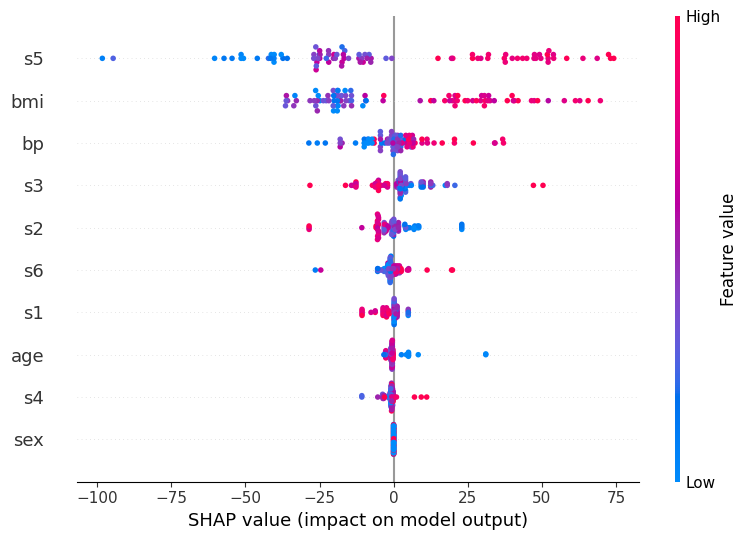

In [23]:
dtree = tree.DecisionTreeRegressor(max_depth=5)
dtree.fit(X_train, y_train)
print_accuracy(dtree.predict)

# explain all the predictions in the test set
ex = shap.TreeExplainer(dtree)
shap_values = ex.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

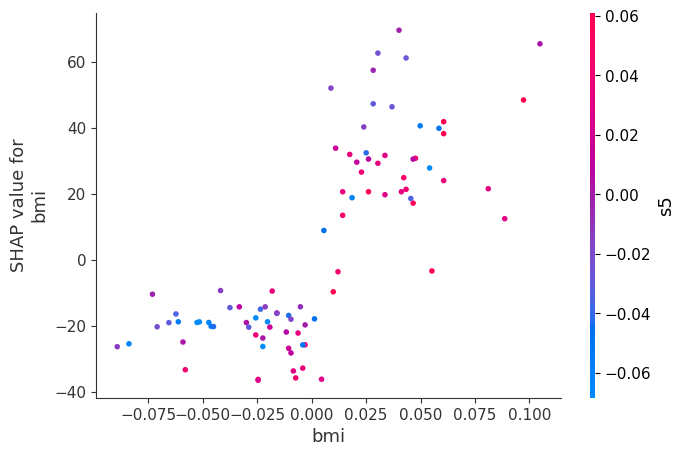

In [24]:
shap.initjs()
shap.dependence_plot('bmi', shap_values, X_test)

In [25]:
shap.initjs()
shap.force_plot(ex.expected_value, shap_values, X_test)

## 3. Neural Network (MLP Regressor)

Train an `MLPRegressor` (2 hidden layers with 5 and 2 units) and explain it with `KernelExplainer` again, since neural networks aren't natively supported by `TreeExplainer`. As before we inspect the summary plot, the `bmi` dependence plot, and the full force plot to see how the model's (non-linear) predictions are driven by the input features.


/Users/antonioponti/miniconda3/envs/mlenv/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:602: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


Root mean squared test error = 58.27512283915021


  0%|          | 0/89 [00:00<?, ?it/s]

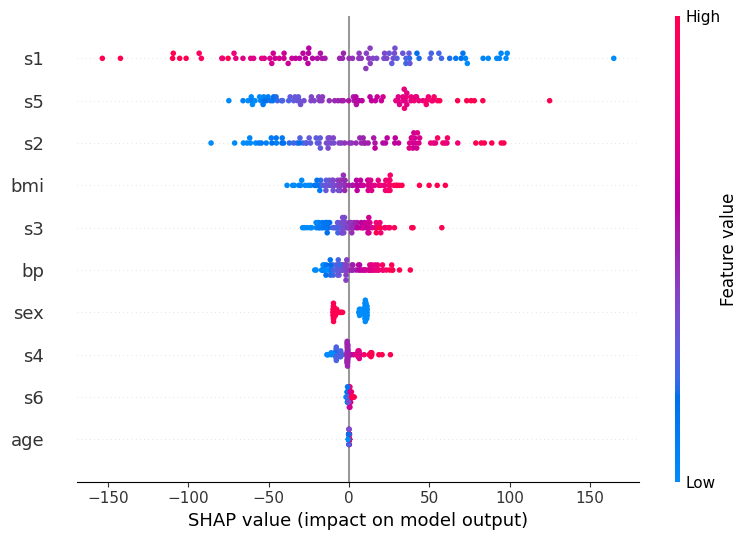

In [26]:
nn = MLPRegressor(solver='lbfgs', alpha=1e-1, hidden_layer_sizes=(5, 2), random_state=0)
nn.fit(X_train, y_train)
print_accuracy(nn.predict)

# explain all the predictions in the test set
explainer = shap.KernelExplainer(nn.predict, X_train_summary)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

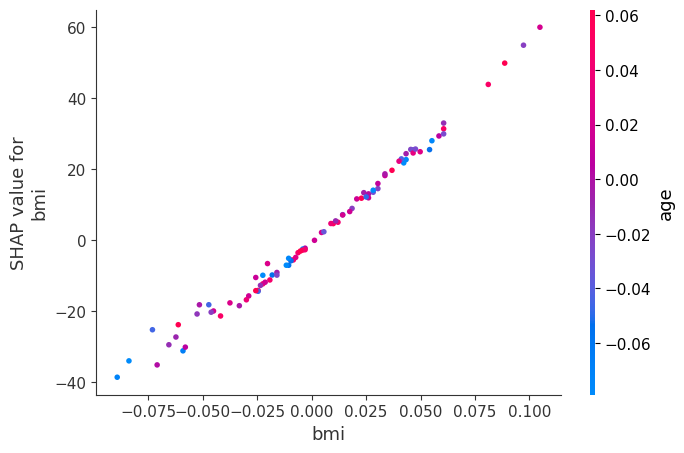

In [27]:
shap.initjs()
shap.dependence_plot('bmi', shap_values, X_test)

In [28]:
shap.initjs()
shap.force_plot(explainer.expected_value, shap_values, X_test)